# **BERT Fine-Tuning**

In [1]:
# Install required libraries
!pip install transformers datasets evaluate scikit-learn torch matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Check if GPU is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# 1. Load the IMDB dataset
dataset = load_dataset("imdb")

# 2. Data Preprocessing (Mandatory)
def clean_text(example):
    """Removes HTML tags and normalizes text."""
    text = example['text']
    text = re.sub(r'<br\s*/?>', ' ', text) # Remove <br /> tags
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    example['text'] = text
    return example

print("Cleaning text data...")
dataset = dataset.map(clean_text)

# Handle missing values (Filter out any None/Null texts)
dataset = dataset.filter(lambda x: x['text'] is not None and x['label'] is not None)

Cleaning text data...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [5]:
# Split training data into Train and Validation (80/20 split)
train_val_split = dataset['train'].train_test_split(test_size=0.2, seed=42)

# Final Dataset Dictionary
final_datasets = {
    'train': train_val_split['train'],
    'validation': train_val_split['test'],
    'test': dataset['test']
}
print(f"Train size: {len(final_datasets['train'])}")
print(f"Validation size: {len(final_datasets['validation'])}")
print(f"Test size: {len(final_datasets['test'])}")

# Tokenization
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    # Truncate and pad texts to a max length suitable for BERT
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing datasets...")
tokenized_datasets = {
    split: final_datasets[split].map(tokenize_function, batched=True)
    for split in final_datasets.keys()
}

Train size: 20000
Validation size: 5000
Test size: 25000


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets...


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

--- EXPERIMENT 1: FREEZE BERT LAYERS ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.682117,0.678533,0.586200,0.679374,0.555359,0.874701
2,0.669294,0.669389,0.612200,0.693729,0.574118,0.876297
3,0.666314,0.666122,0.634000,0.700785,0.593629,0.855148


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating Experiment 1 on Test Set...


{'test_loss': 0.6668235659599304, 'test_accuracy': 0.6286, 'test_f1': 0.6967172954434101, 'test_precision': 0.5887386144079492, 'test_recall': 0.8532, 'test_runtime': 224.1903, 'test_samples_per_second': 111.512, 'test_steps_per_second': 6.972}


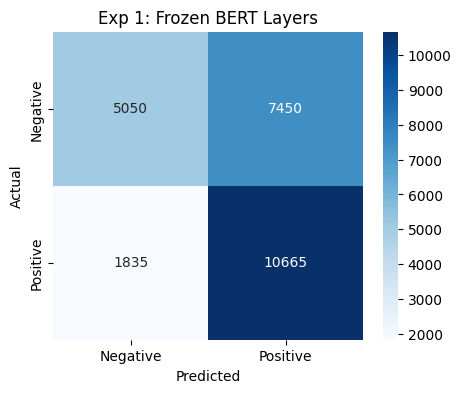

In [9]:
print("--- EXPERIMENT 1: FREEZE BERT LAYERS ---")

# Load pre-trained BERT model
model_frozen = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Freeze all BERT layers
for param in model_frozen.bert.parameters():
    param.requires_grad = False

# Set Training Arguments (AdamW is default, Learning Rate: 2e-5)
training_args_1 = TrainingArguments(
    output_dir="./results_exp1",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50
)

trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args_1,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
)

# Train the model
trainer_frozen.train()

# Evaluate on Test Set
print("\nEvaluating Experiment 1 on Test Set...")
predictions_1 = trainer_frozen.predict(tokenized_datasets['test'])
print(predictions_1.metrics)

# Plot Confusion Matrix
y_true_1 = tokenized_datasets['test']['label']
y_pred_1 = np.argmax(predictions_1.predictions, axis=-1)
plot_confusion_matrix(y_true_1, y_pred_1, title="Exp 1: Frozen BERT Layers")

--- EXPERIMENT 2: FINE-TUNE LAST 2 LAYERS ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.334601,0.322393,0.867800,0.866761,0.875764,0.857941
2,0.316415,0.311072,0.872200,0.874089,0.863371,0.885076
3,0.244518,0.306833,0.874800,0.874398,0.879338,0.869513


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating Experiment 2 on Test Set...


{'test_loss': 0.2996790409088135, 'test_accuracy': 0.8774, 'test_f1': 0.8771690778663888, 'test_precision': 0.87882437966755, 'test_recall': 0.87552, 'test_runtime': 217.1113, 'test_samples_per_second': 115.148, 'test_steps_per_second': 7.199}


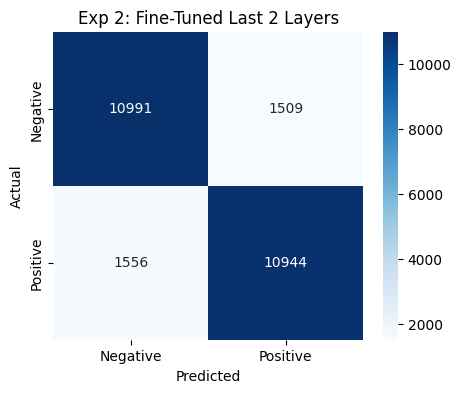

In [10]:
print("--- EXPERIMENT 2: FINE-TUNE LAST 2 LAYERS ---")

# Load a fresh pre-trained BERT model
model_tuned = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Freeze all layers first
for param in model_tuned.bert.parameters():
    param.requires_grad = False

# Unfreeze the last 2 layers of the encoder (BERT has 12 layers: indices 0 to 11)
for param in model_tuned.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

# Also unfreeze the pooler layer (connects the encoder to the classification head)
for param in model_tuned.bert.pooler.parameters():
    param.requires_grad = True

# Set Training Arguments
training_args_2 = TrainingArguments(
    output_dir="./results_exp2",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50
)

trainer_tuned = Trainer(
    model=model_tuned,
    args=training_args_2,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
)

# Train the model
trainer_tuned.train()

# Evaluate on Test Set
print("\nEvaluating Experiment 2 on Test Set...")
predictions_2 = trainer_tuned.predict(tokenized_datasets['test'])
print(predictions_2.metrics)

# Plot Confusion Matrix
y_true_2 = tokenized_datasets['test']['label']
y_pred_2 = np.argmax(predictions_2.predictions, axis=-1)
plot_confusion_matrix(y_true_2, y_pred_2, title="Exp 2: Fine-Tuned Last 2 Layers")

--- COMPARING PERFORMANCE ACROSS EXPERIMENTS ---

Performance Comparison Table:


,Metric,Exp 1: Frozen Layers,Exp 2: Fine-Tuned Last 2 Layers
0,Accuracy,0.628600,0.877400
1,Precision,0.588739,0.878824
2,Recall,0.853200,0.875520
3,F1 Score,0.696717,0.877169


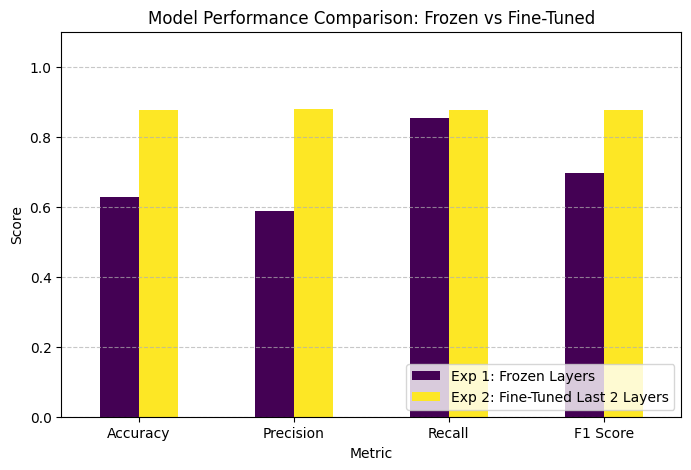

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- COMPARING PERFORMANCE ACROSS EXPERIMENTS ---")

# Extract metrics from previous predictions
metrics_exp1 = predictions_1.metrics
metrics_exp2 = predictions_2.metrics

# Create a dictionary for the DataFrame
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Exp 1: Frozen Layers": [
        metrics_exp1['test_accuracy'],
        metrics_exp1['test_precision'],
        metrics_exp1['test_recall'],
        metrics_exp1['test_f1']
    ],
    "Exp 2: Fine-Tuned Last 2 Layers": [
        metrics_exp2['test_accuracy'],
        metrics_exp2['test_precision'],
        metrics_exp2['test_recall'],
        metrics_exp2['test_f1']
    ]
}

# Create and display the DataFrame table
df_compare = pd.DataFrame(comparison_data)
print("\nPerformance Comparison Table:")
display(df_compare)

# Plotting the comparison as a grouped bar chart
df_compare.set_index("Metric").plot(kind="bar", figsize=(8, 5), colormap="viridis")
plt.title("Model Performance Comparison: Frozen vs Fine-Tuned")
plt.ylabel("Score")
plt.ylim(0, 1.1) # Set y-axis limit from 0 to 1.1 for better visibility
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

--- BONUS TASK: DistilBERT with Early Stopping & LR Scheduler ---


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Evaluating Bonus Model on Test Set...


{'test_loss': 0.31865260004997253, 'test_accuracy': 0.86764, 'test_f1': 0.8616465275745285, 'test_precision': 0.9025137952176578, 'test_recall': 0.82432, 'test_runtime': 108.1875, 'test_samples_per_second': 231.08, 'test_steps_per_second': 14.447}


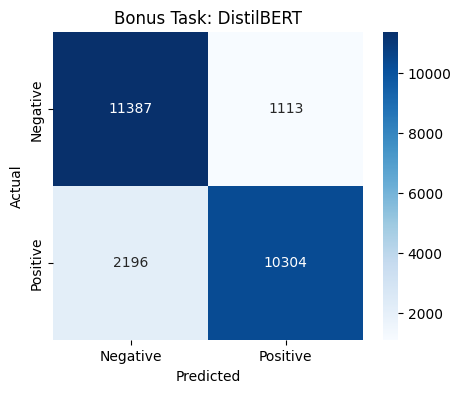

In [12]:
from transformers import EarlyStoppingCallback

print("--- BONUS TASK: DistilBERT with Early Stopping & LR Scheduler ---")

# 1. Load DistilBERT Tokenizer and re-tokenize (Best practice when switching models)
distil_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def distil_tokenize_function(examples):
    return distil_tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing data for DistilBERT...")
distil_tokenized_datasets = {
    split: final_datasets[split].map(distil_tokenize_function, batched=True)
    for split in final_datasets.keys()
}

# 2. Load pre-trained DistilBERT model
bonus_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# 3. Set Training Arguments with Bonus Features
bonus_training_args = TrainingArguments(
    output_dir="./results_bonus",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,            # Set higher epochs to give Early Stopping a chance to trigger
    weight_decay=0.01,
    lr_scheduler_type="cosine",    # BONUS: Learning Rate Scheduler (Cosine Annealing)
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_dir='./logs_bonus',
    logging_steps=50
)

# 4. Initialize Trainer with Early Stopping Callback
bonus_trainer = Trainer(
    model=bonus_model,
    args=bonus_training_args,
    train_dataset=distil_tokenized_datasets['train'],
    eval_dataset=distil_tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

# Train the Bonus Model
print("\nTraining Bonus Model...")
bonus_trainer.train()

# Evaluate the Bonus Model on Test Set
print("\nEvaluating Bonus Model on Test Set...")
bonus_predictions = bonus_trainer.predict(distil_tokenized_datasets['test'])
print(bonus_predictions.metrics)

# Plot Confusion Matrix for Bonus Model
y_true_bonus = distil_tokenized_datasets['test']['label']
y_pred_bonus = np.argmax(bonus_predictions.predictions, axis=-1)
plot_confusion_matrix(y_true_bonus, y_pred_bonus, title="Bonus Task: DistilBERT")

# **Final Analysis & Insights**

1. **Frozen vs. Fine-Tuning (Exp 1 vs 2)**: As shown in the comparison graph,
fine-tuning the last 2 layers of BERT significantly outperforms the completely frozen model. Freezing the layers forces the model to rely entirely on general pre-trained embeddings, which aren't optimized for the specific vocabulary and sentiment of IMDB movie reviews. Unfreezing just the top 2 layers allows the model to adapt its contextual understanding, resulting in higher accuracy and F1 scores.

2. **Bonus Task (DistilBERT)**: By utilizing DistilBERT, the model trained noticeably faster due to having fewer parameters than BERT-base.

3. **Learning Rate & Early Stopping**: Implementing a cosine learning rate scheduler allowed the model to take larger steps initially and fine-tune delicately at the end. The Early Stopping callback prevented overfitting by halting training when the validation accuracy stopped improving, saving computation time and ensuring the best model weights were restored.